![Logo ITQ](img/imagen1.png)

**Nombre:** Alexis Arcos
<br>
**Fecha:** 13/04/2026

![Logo Python](img/imagen2.png)

## **NUESTRA PRIMERA RED NEURONAL: MNIST DATASET**

In [1]:
!pip install $packageName

ERROR: Invalid requirement: '$packageName': Expected package name at the start of dependency specifier
    $packageName
    ^


In [2]:
!pip freeze

absl-py==2.4.0
aext-assistant @ file:///C:/b/abs_1bfn_ondsd/croot/aext-assistant_1746560154452/work
aext-assistant-server @ file:///C:/b/abs_6f6umrladb/croot/aext-assistant-server_1746552992573/work
aext-core @ file:///C:/b/abs_a0497039ax/croot/aext-core_1746546102863/work
aext-core-server @ file:///C:/b/abs_82tjab_7w4/croot/aext-core-server_1746542360244/work
aext-panels @ file:///C:/b/abs_fde530cwui/croot/aext-panels_1746560097533/work
aext-panels-server @ file:///C:/b/abs_6672ttq6cc/croot/aext-panels-server_1746552976245/work
aext-project-filebrowser-server @ file:///C:/b/abs_79l9wkmqos/croot/aext-project-filebrowser-server_1746563508758/work/backend_lib/project_filebrowser
aext-share-notebook @ file:///C:/b/abs_4dnd8bg_5y/croot/aext-share-notebook_1746556779074/work
aext-share-notebook-server @ file:///C:/b/abs_33583xtbk0/croot/aext-share-notebook-server_1746552715592/work
aext-shared @ file:///C:/b/abs_4fe5it0ngg/croot/aext-shared_1746540522892/work
aext-toolbox @ file:///C:/b/abs

Hola voy a ejecutar el comando ```!pip freeze``` para cotillear a Google Colab

In [3]:
!nvidia-smi

"nvidia-smi" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [4]:
#Importemos TensorFlow 2.X y Numpy
import numpy as np
import tensorflow as tf
tf.__version__

'2.21.0'

#### **- Cargando el conjunto de datos**

In [5]:
# Importamos el dataset MNIST y cargamos los datos
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


#### **- Inspeccionando el conjunto de datos**

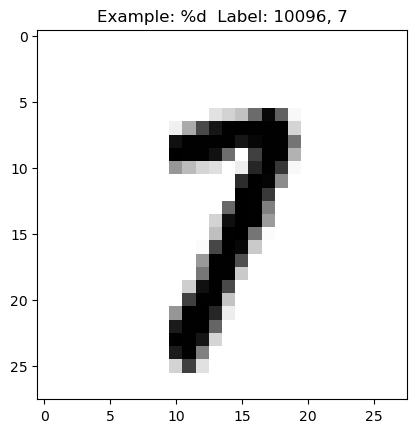

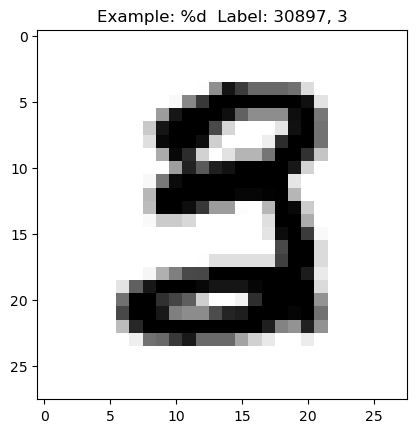

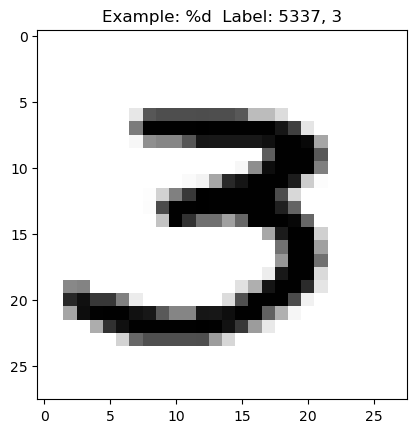

In [6]:
import matplotlib.pyplot as plt
# Función auxiliar para visualizar datos de entrenamiento de manera aleatoria
def display_digit(num,x_train,y_train):
  # Seleccionar la imagen num de mnist.train.images y hacer un reshape al tamaño de la imagen
  image = x_train[num,:,:]
  # Seleccionar el target num de mnist.train.labels
  label = y_train[num]
  # Mostrar
  plt.title(f'Example: %d  Label: {num}, {label}')
  plt.imshow(image, cmap=plt.get_cmap('gray_r'))
  plt.show()

# Mostramos algunos ejemplos
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)

In [7]:
np.random.randint(0, x_train.shape[0])

39176

#### **- Acondicionando el conjunto de datos**

In [8]:
# Pre-procesado obligatorio cuando trabajo con redes neuronales
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten
from sklearn.model_selection import train_test_split

x_train, x_te = x_train / 255.0, x_test / 255.0 #Cambio al rango 0-1 -> Disminuyo CC
y_train = to_categorical(y_train, num_classes=10) #One-hot encoding para minimizar error
print(y_train.shape)
y_te = to_categorical(y_test, num_classes=10)
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42) # 3 subconjuntos es de vital importancia
print(y_tr.shape)
# print(y_tr[0])

(60000, 10)
(54000, 10)


In [9]:
print(y_tr[5214])

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [10]:
print(y_tr[5214].argmax(axis=0))

4


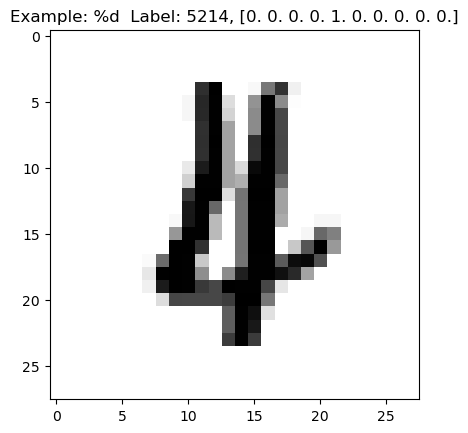

In [11]:
display_digit(5214, x_tr,y_tr)

#### **- Creando la topología de Red Neuronal (MLP) y entrenándola**

In [12]:
# Voy a necesitar importar una serie de modulos para programar mi red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
# Vamos a codificar la topología de nuestra primera red neuronal!!!
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(512, input_shape=(28*28,), activation="relu"))
model.add(Dense(10, activation="softmax")) #Capa salida -> Mismo número de neuronas que de clases objetivo

# Ahí tenemos nuestro primer MLP con una única capa oculta de 512 neuronas

C:\Users\RYZEN\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\RYZEN\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
#Traigamos nuestro optimizador
from tensorflow.keras.optimizers import SGD
# Ahora que tengo definida la arquitectura, la compilo
model.compile(loss="categorical_crossentropy", optimizer=SGD(0.005), metrics=["accuracy"])

In [14]:
######### Modelo funcional ############ (Clase 04/10/2023)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import SGD

# Definir la entrada
input_layer = Input(shape=(28, 28))

# Capa de aplanamiento
x = Flatten()(input_layer)
x = Dense(512, activation="relu")(x)
# x = Dropout(0.5)(x)  # Introducción de capa de dropout en un modelo funcional
output_layer = Dense(10, activation="softmax")(x)

# Crear el modelo
model = Model(inputs=input_layer, outputs=output_layer)

# Compilar el modelo
model.compile(
    loss="categorical_crossentropy",
    optimizer=SGD(learning_rate=0.005),
    metrics=["accuracy"]
)

# Guardamos este modelo para usarlo después en la predicción de imágenes
model_mnist = model


In [15]:
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
# Por fin podemos entrenar nuestra primera red neuronal
print("[INFO]: Entrenando red neuronal...")
H = model.fit(x_tr, y_tr, validation_data=(x_val, y_val), epochs=50, batch_size=128)
model_mnist = model


[INFO]: Entrenando red neuronal...
Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6481 - loss: 1.5180 - val_accuracy: 0.7982 - val_loss: 1.0017
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8281 - loss: 0.8014 - val_accuracy: 0.8503 - val_loss: 0.6685
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8586 - loss: 0.5982 - val_accuracy: 0.8663 - val_loss: 0.5438
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8732 - loss: 0.5084 - val_accuracy: 0.8778 - val_loss: 0.4774
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8829 - loss: 0.4568 - val_accuracy: 0.8863 - val_loss: 0.4361
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8894 - loss: 0.4227 - val_accuracy: 0.8917 - val_loss: 0.4081
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8938 - loss: 0.3982 - val_accuracy: 0.8948 - val_loss: 0.3860
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.898

#### **- Observando el proceso de entrenamiento para tomar decisiones**

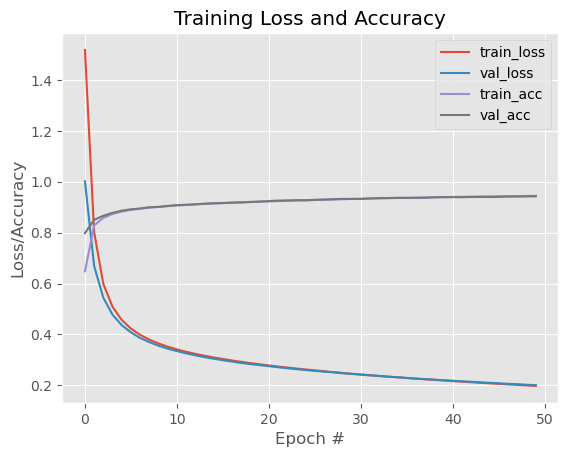

In [17]:
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 50), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 50), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

#### **- Probando el conjunto de datos en el subset de test y evaluando el performance del modelo**

In [18]:
from sklearn.metrics import classification_report
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
predictions = model.predict(x_te, batch_size=128)
print(y_te[0])
print(predictions[0])
print(classification_report(y_te.argmax(axis=1), predictions.argmax(axis=1)))

[INFO]: Evaluando red neuronal...
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[8.7733883e-05 5.3629566e-07 4.4108194e-04 2.8113225e-03 2.2942813e-06
 6.7436828e-05 6.4540572e-08 9.9613684e-01 3.5607238e-05 4.1703586e-04]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.95      0.94      0.94      1032
           3       0.93      0.94      0.93      1010
           4       0.94      0.95      0.94       982
           5       0.94      0.91      0.93       892
           6       0.95      0.96      0.95       958
           7       0.95      0.94      0.94      1028
           8       0.93      0.93      0.93       974
           9       0.93      0.92      0.93      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.94      0.94     10000
weighted avg       0.95      0.95      0.95   

In [19]:
predictions[0].argmax(axis=0)

np.int64(7)

In [20]:
y_te[0].argmax(axis=0)

np.int64(7)

In [21]:
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,052 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None


--------------------------------------------------------------------------

## **MLP APLICADO A TEXTO: EJEMPLO REUTERS**

#### **- Cargando el conjunto de datos**

In [22]:
import numpy as np
import tensorflow as tf
# Importamos el dataset REUTERS y cargamos los datos
reuters = tf.keras.datasets.reuters
WORD_LIMIT = 10000
(training_data, training_labels), (testing_data, testing_labels) = reuters.load_data(num_words=WORD_LIMIT)
print(training_data.shape)
print(training_labels.shape)
print(testing_data.shape)
print(testing_labels.shape)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(8982,)
(8982,)
(2246,)
(2246,)


#### **- Inspeccionando el conjunto de datos**

In [23]:
# Los datos son numericos para decodificarlos, se puede usar reuters.get_word_index()
word_index = reuters.get_word_index()
reverse_word_index = dict({value : key for key, value in word_index.items()})
decoded = ' '.join(
    [reverse_word_index.get(i-3,'?') for i in training_data[5]]
)
decoded

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


"? the u s agriculture department estimated canada's 1986 87 wheat crop at 31 85 mln tonnes vs 31 85 mln tonnes last month it estimated 1985 86 output at 24 25 mln tonnes vs 24 25 mln last month canadian 1986 87 coarse grain production is projected at 27 62 mln tonnes vs 27 62 mln tonnes last month production in 1985 86 is estimated at 24 95 mln tonnes vs 24 95 mln last month canadian wheat exports in 1986 87 are forecast at 19 00 mln tonnes vs 18 00 mln tonnes last month exports in 1985 86 are estimated at 17 71 mln tonnes vs 17 72 mln last month reuter 3"

#### **- Acondicionando el conjunto de datos**

In [24]:
# Función auxiliar para representar las palabras (que no entiende nuestra red neuronal) en números
import numpy as np
# one hot encoding del input, vector con cada indice indicando si una palabra esta presente
def one_hot_encode(data):
    encoded = np.zeros((len(data),WORD_LIMIT))
    for i, v in enumerate(data):
        encoded[i,v] = 1 # localiza las columnas del genero correspondiente, marca con 1
    return encoded

In [25]:
# Convertimos nuestras palabras a números
x_train = one_hot_encode(training_data)
x_test = one_hot_encode(testing_data)
print(x_train.shape)
print(x_test.shape)

(8982, 10000)
(2246, 10000)


In [26]:
print(x_test[3])

[0. 1. 1. ... 0. 0. 0.]


In [27]:
# Convertimos nuestros labels (categoría reseña) a one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(training_labels)
y_test = to_categorical(testing_labels)
print(y_train.shape)
print(y_test.shape)

(8982, 46)
(2246, 46)


In [28]:
print(y_test[3])

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


#### **- Creando la topología de Red Neuronal (MLP) y entrenándola**

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Vamos a codificar la topología de nuestro MLP
model = Sequential()
model.add(Dense(128,activation='relu',input_shape=(WORD_LIMIT,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes
# En el caso de regresión cambiamos la ultima capa por:
#model.add(Dense(1,activation='sigmoid'))

C:\Users\RYZEN\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
# Ahora que tengo definida la arquitectura, la compilo
model.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase/ para regresion (mse/mae)
               metrics=['accuracy'])

In [31]:
# A entrenar nuestra red neuronal sea dicho!
H = model.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6754 - loss: 1.5086 - val_accuracy: 0.7846 - val_loss: 1.0116
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8713 - loss: 0.5855 - val_accuracy: 0.8164 - val_loss: 0.8495
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9381 - loss: 0.2826 - val_accuracy: 0.8063 - val_loss: 0.8894
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9541 - loss: 0.1983 - val_accuracy: 0.7986 - val_loss: 0.9425
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9577 - loss: 0.1573 - val_accuracy: 0.7969 - val_loss: 0.9788
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9589 - loss: 0.1431 - val_accuracy: 0.8097 - val_loss: 1.0129
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9595 - loss: 0.1325 - val_accuracy: 0.8047 - val_loss: 0.9886
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9617 - loss: 0.1155 - val_accuracy: 0.

#### **- Observando el proceso de entrenamiento para tomar decisiones**

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,874,124 (14.78 MB)

 Trainable params: 1,291,374 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,582,750 (9.85 MB)

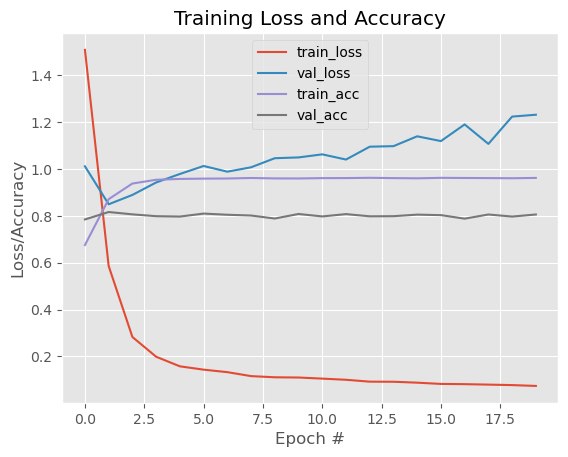

In [33]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

#### **- Probando el conjunto de datos en el subset de test y evaluando el performance del modelo**

In [34]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model.predict(x_test)
loss, accuracy = model.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7947 - loss: 1.2605  
Loss 1.2605289220809937, accuracy 0.7947462201118469


## **REGULARIZACIÓN EN APRENDIZAJE PROFUNDO**

#### **- Weight regularization L1/L2**

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers
# Vamos a codificar la topología de nuestro MLP
model_reg = Sequential()
model_reg.add(Dense(128,activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(WORD_LIMIT,)))
model_reg.add(Dense(64,activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model_reg.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

C:\Users\RYZEN\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
# Ahora que tengo definida la arquitectura, la compilo
model_reg.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [37]:
# A entrenar nuestra red neuronal sea dicho!
H = model_reg.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6480 - loss: 2.3961 - val_accuracy: 0.7134 - val_loss: 1.8302
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7344 - loss: 1.6927 - val_accuracy: 0.7195 - val_loss: 1.7345
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7493 - loss: 1.5997 - val_accuracy: 0.7373 - val_loss: 1.6600
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7608 - loss: 1.5389 - val_accuracy: 0.7323 - val_loss: 1.6486
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7712 - loss: 1.5123 - val_accuracy: 0.7501 - val_loss: 1.5751
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7756 - loss: 1.4758 - val_accuracy: 0.7574 - val_loss: 1.5978
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7825 - loss: 1.4499 - val_accuracy: 0.7518 - val_loss: 1.5766
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7861 - loss: 1.4142 - val_accuracy: 0.

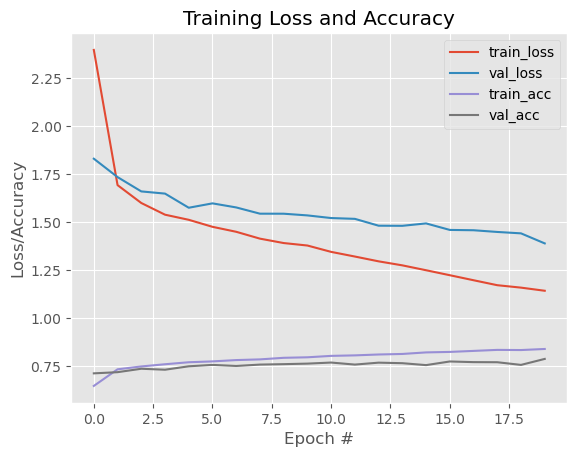

In [38]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [39]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_reg.predict(x_test)
loss, accuracy = model_reg.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7711 - loss: 1.4279
Loss 1.4278682470321655, accuracy 0.771148681640625


#### **- Dropout**

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
# Vamos a codificar la topología de nuestro MLP
model_drop = Sequential()
model_drop.add(Dense(128,activation='relu', input_shape=(WORD_LIMIT,)))
#model_drop.add(Dropout(0.5))
model_drop.add(Dropout(0.55))
model_drop.add(Dense(64,activation='relu'))
#model_drop.add(Dropout(0.5))
model_drop.add(Dropout(0.55))
model_drop.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

C:\Users\RYZEN\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
# Ahora que tengo definida la arquitectura, la compilo
model_drop.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [42]:
# A entrenar nuestra red neuronal sea dicho!
H = model_drop.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5261 - loss: 2.0258 - val_accuracy: 0.6989 - val_loss: 1.3415
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6772 - loss: 1.3624 - val_accuracy: 0.7407 - val_loss: 1.1529
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7272 - loss: 1.1166 - val_accuracy: 0.7635 - val_loss: 1.0650
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7692 - loss: 0.9574 - val_accuracy: 0.7852 - val_loss: 1.0195
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7982 - loss: 0.8248 - val_accuracy: 0.7830 - val_loss: 1.0207
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8082 - loss: 0.7697 - val_accuracy: 0.7902 - val_loss: 0.9999
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8235 - loss: 0.6891 - val_accuracy: 0.7869 - val_loss: 0.9950
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8384 - loss: 0.6301 - val_accuracy: 0.

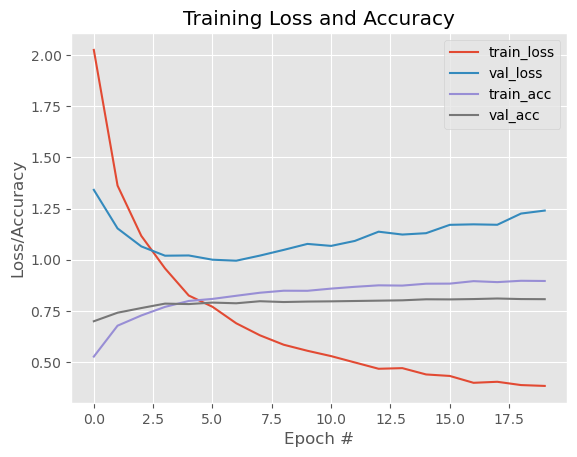

In [43]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

# ¿Y si desconectamos mayor porcentaje de neuronas?

In [44]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_drop.predict(x_test)
loss, accuracy = model_drop.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7988 - loss: 1.3757
Loss 1.3757436275482178, accuracy 0.7987533211708069


#### **- Batch Normalization**

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
# Vamos a codificar la topología de nuestro MLP
model_bn = Sequential()
model_bn.add(Dense(128,activation='relu', input_shape=(WORD_LIMIT,)))
model_bn.add(BatchNormalization())
model_bn.add(Dropout(0.6))
model_bn.add(Dense(64,activation='relu'))
model_bn.add(BatchNormalization())
model_bn.add(Dropout(0.6))
model_bn.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

C:\Users\RYZEN\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
# Ahora que tengo definida la arquitectura, la compilo
model_bn.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [47]:
# A entrenar nuestra red neuronal sea dicho!
H = model_bn.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4505 - loss: 2.6002 - val_accuracy: 0.6678 - val_loss: 1.8045
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6612 - loss: 1.6083 - val_accuracy: 0.7318 - val_loss: 1.2510
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7080 - loss: 1.3159 - val_accuracy: 0.7646 - val_loss: 1.1251
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7413 - loss: 1.1347 - val_accuracy: 0.7858 - val_loss: 1.0604
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7641 - loss: 1.0109 - val_accuracy: 0.7896 - val_loss: 1.0196
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7839 - loss: 0.9049 - val_accuracy: 0.7935 - val_loss: 0.9831
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8000 - loss: 0.8239 - val_accuracy: 0.7935 - val_loss: 0.9796
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8145 - loss: 0.7611 - val_accuracy: 0.

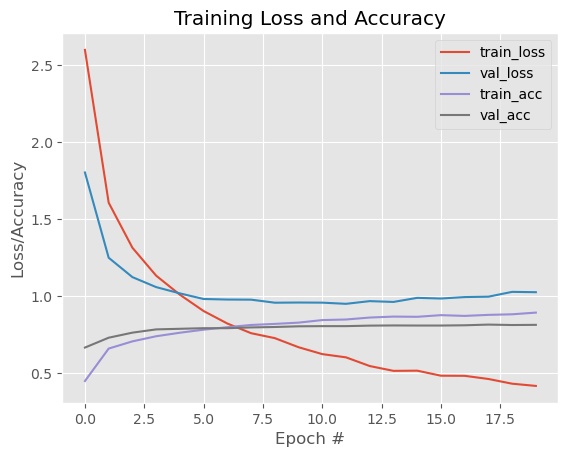

In [48]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [49]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_bn.predict(x_test)
loss, accuracy = model_bn.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8054 - loss: 1.0621
Loss 1.0620746612548828, accuracy 0.8054319024085999


Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9533 - loss: 0.1545 - val_accuracy: 0.9850 - val_loss: 0.0507
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9798 - loss: 0.0674 - val_accuracy: 0.9842 - val_loss: 0.0593
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9846 - loss: 0.0528 - val_accuracy: 0.9880 - val_loss: 0.0493
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9874 - loss: 0.0434 - val_accuracy: 0.9853 - val_loss: 0.0496
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9887 - loss: 0.0381 - val_accuracy: 0.9873 - val_loss: 0.0548
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9911 - loss: 0.0296 - val_accuracy: 0.9862 - val_loss: 0.0734


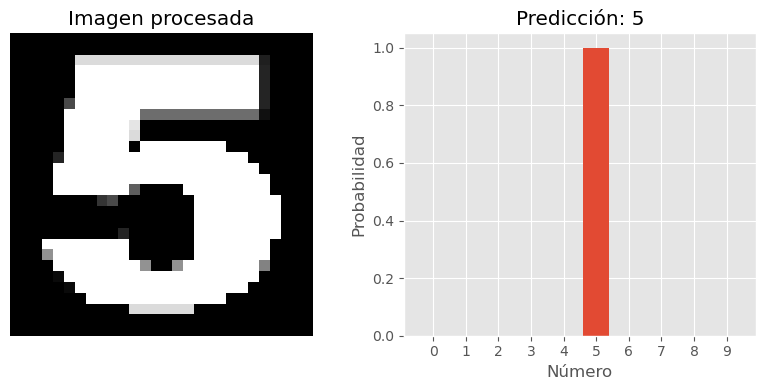

Número predicho: 5
Confianza: 100.00%


In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPooling2D, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# ==================================================
# 1. Cargar datos de entrenamiento
# ==================================================
(x_train, y_train), _ = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)

# ==================================================
# 2. Crear el modelo
# ==================================================
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# ==================================================
# 3. Compilar
# ==================================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==================================================
# 4. Entrenar
# ==================================================
parada = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model.fit(
    x_train, y_train,
    epochs=8,
    validation_split=0.1,
    callbacks=[parada],
    verbose=1
)

# ==================================================
# 5. Preparar imagen
# ==================================================
def preparar_imagen(ruta):
    imagen = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    if imagen is None:
        raise FileNotFoundError(f"No se pudo abrir la imagen: {ruta}")

    # Redimensionar para trabajar mejor
    imagen = cv2.resize(imagen, (100, 100))

    # Invertir colores: fondo negro, número blanco
    imagen = 255 - imagen

    # Pasar a blanco y negro
    _, imagen = cv2.threshold(imagen, 100, 255, cv2.THRESH_BINARY)

    # Buscar el número dentro de la imagen
    puntos = cv2.findNonZero(imagen)
    if puntos is None:
        raise ValueError("No se detectó ningún número en la imagen.")

    x, y, w, h = cv2.boundingRect(puntos)
    recorte = imagen[y:y+h, x:x+w]

    # Crear fondo cuadrado para centrar el número
    lado = max(w, h) + 20
    fondo = np.zeros((lado, lado), dtype=np.uint8)

    pos_x = (lado - w) // 2
    pos_y = (lado - h) // 2
    fondo[pos_y:pos_y+h, pos_x:pos_x+w] = recorte

    # Ajustar al tamaño de MNIST
    fondo = cv2.resize(fondo, (28, 28))
    fondo = fondo.astype("float32") / 255.0

    return fondo

# ==================================================
# 6. Hacer predicción
# ==================================================
ruta_imagen = "img/numeros.jpg"   # cambia esta ruta por tu imagen

try:
    imagen_lista = preparar_imagen(ruta_imagen)

    entrada = imagen_lista.reshape(1, 28, 28, 1)
    prediccion = model.predict(entrada, verbose=0)

    numero = np.argmax(prediccion)
    confianza = np.max(prediccion) * 100

    # Mostrar imagen y resultado
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(imagen_lista, cmap="gray")
    plt.title("Imagen procesada")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.bar(range(10), prediccion[0])
    plt.xticks(range(10))
    plt.xlabel("Número")
    plt.ylabel("Probabilidad")
    plt.title(f"Predicción: {numero}")

    plt.tight_layout()
    plt.show()

    print(f"Número predicho: {numero}")
    print(f"Confianza: {confianza:.2f}%")

except Exception as e:
    print("Error:", e)

### 4. Github

https://github.com/alexis77710/machine-learning-introduccion.git